# Extract Feature from Each Frame

In [106]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [107]:

feature_scaler = StandardScaler()

# extract features from the CSV file
def extract_frame_features(frame_df, scaler=None):
    num_objects = len(frame_df)
    avg_conf = frame_df["confidence"].mean()
    avg_box_area = ((frame_df["x_max"] - frame_df["x_min"]) *
                    (frame_df["y_max"] - frame_df["y_min"])).mean()

    desired_size = 13
    class_counts = np.zeros(desired_size)

    for cls in frame_df["object_class"]:
        cls = int(cls)
        if cls < desired_size:
            class_counts[cls] += 1

    raw_features = [num_objects, avg_conf, avg_box_area] + class_counts.tolist()
    
    if scaler:
        raw_features = scaler.transform([raw_features])[0]  # normalize
    return torch.tensor(raw_features, dtype=torch.float32)


# Process the CSV file and extract features for each frame
def process_video_csv(csv_path, scaler = None):
    df = pd.read_csv(csv_path)

    sequences = []
    if "frame" not in df.columns or df.empty:
        return torch.empty(0, 16)  # return empty tensor with correct shape

    for _, frame_df in df.groupby("frame"):
        frame_feat = extract_frame_features(frame_df, scaler = scaler)
        sequences.append(frame_feat)

    if not sequences:
        return torch.empty(0, 16)  
    return torch.stack(sequences)




# Load Data Labels

In [ ]:
import csv

# Load label CSV into a dictionary
label_dict = {}
with open("../../data/train_labels.csv", newline = "") as f:
    reader = csv.DictReader(f)
    for row in reader:
        label_dict[row["id"]] = int(row["target"])

# Split Data into Training, Validation, and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Get all video directories
video_dirs = sorted([
    os.path.join("../../data/yolo_processed_data", d)
    for d in os.listdir("../../data/yolo_processed_data")
    if os.path.isdir(os.path.join("../../data/yolo_processed_data", d))
])

# Initialize an empty list to store video_ids
video_ids = []

# Extract video IDs from the directory names, removing video_ prefix
for video_dir in video_dirs:
    video_id = os.path.basename(video_dir).replace("video_", "")
    if video_id in label_dict:
        video_ids.append(video_id)
    else:
        raise AssertionError(f"Label missing for video: {video_id}")


# Split the video IDs
train_ids, temp_ids = train_test_split(video_ids, test_size = 0.2)
val_ids, test_ids = train_test_split(temp_ids, test_size = 0.5)


# Initialize empty lists to store the video directories
train_videos = []
val_videos = []
test_videos = []

# Populate the train_videos list with the corresponding directories
for video_id in train_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    train_videos.append(video_dir)

# Populate the val_videos list with the corresponding directories
for video_id in val_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    val_videos.append(video_dir)

# Populate the test_videos list with the corresponding directories
for video_id in test_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    test_videos.append(video_dir)

In [110]:
# Shape Sanity Check
print(f"-----Dataset Sizes-----")
print(f"Train videos: {len(train_videos) / len(video_dirs)}")
print(f"Validation videos: {len(val_videos) / len(video_dirs)}")
print(f"Test videos: {len(test_videos) / len(video_dirs)}\n")


print(f"-----Dataset Values-----")
print(f"Train Videos: {train_videos[0:2]}")
print(f"Validation Videos: {val_videos[0:2]}")
print(f"Test Videos: {test_videos[0:2]}")

-----Dataset Sizes-----
Train videos: 0.8
Validation videos: 0.1
Test videos: 0.1

-----Dataset Values-----
Train Videos: ['../data/yolo_processed_data/video_01122', '../data/yolo_processed_data/video_01754']
Validation Videos: ['../data/yolo_processed_data/video_00106', '../data/yolo_processed_data/video_00903']
Test Videos: ['../data/yolo_processed_data/video_00369', '../data/yolo_processed_data/video_00356']


Before training, we need to compute the mean and standard deviation of each feature from the training set only.

In [111]:
# Preprocess all training features to fit the scaler
all_train_features = []
for video_dir in train_videos:
    csv_path = os.path.join(video_dir, "detections.csv")
    df = pd.read_csv(csv_path)
    for _, frame_df in df.groupby("frame"):
        feat = extract_frame_features(frame_df)
        all_train_features.append(feat.numpy())

feature_scaler.fit(all_train_features)  # fit the scaler on raw features

StandardScaler()

# Create Dataset and DataLoader

In [112]:
# Create a dataset class for the video sequences
class VideoDataset(Dataset):
    def __init__(self, video_dirs, label_dict, scaler=None):
        self.video_dirs = video_dirs
        self.label_dict = label_dict
        self.scaler = scaler

    def __len__(self):
        return len(self.video_dirs)
    
    def __getitem__(self, idx):
        while True:
            video_dir = self.video_dirs[idx]
            video_id = os.path.basename(video_dir).replace("video_", "").zfill(5)
            label = self.label_dict.get(video_id, 0)

            csv_path = os.path.join(video_dir, "detections.csv")
            seq = process_video_csv(csv_path, scaler=self.scaler)

            if seq is None:
                idx = (idx + 1) % len(self.video_dirs)
                return self.__getitem__(idx)

            return seq, torch.tensor(label, dtype=torch.float32)
    
    
# Collate function to pad sequences and create batches
def collate_fn(batch):
    # Filter out samples with empty sequences
    batch = [(x, y) for x, y in batch if x.size(0) > 0]

    if len(batch) == 0:
        return None  # skip batch if empty

    batch.sort(key=lambda x: x[0].size(0), reverse=True)
    sequences, labels = zip(*batch)
    lengths = torch.tensor([seq.size(0) for seq in sequences])

    padded_seqs = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)

    return padded_seqs, lengths, labels



# Create datasets for training and validation
train_dataset = VideoDataset(train_videos, label_dict, scaler=feature_scaler)
val_dataset = VideoDataset(val_videos, label_dict, scaler=feature_scaler)
test_dataset = VideoDataset(test_videos, label_dict, scaler=feature_scaler)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)
test_loader = DataLoader(test_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)

# Define the GRU Model

In [ ]:
# Define the GRU model for classification
class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers = 2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, dropout=0.2, batch_first = True, bidirectional = True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hn = self.gru(packed)  
        out = self.fc(hn[-1])     # Get last hidden state
        return self.sigmoid(out).squeeze()



# Training Loop

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 16  # 3 summary features + 10 class counts
model = GRUClassifier(input_dim, hidden_dim = 128).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001, weight_decay=1e-5)
best_val_loss = float('inf')
patience_counter = 0
patience = 10
train_losses, val_losses = [], []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)


# Training loop
for epoch in range(50):
    model.train()
    train_loss = 0
    for batch in train_loader:
        if batch is None:
            continue

        x_batch, lengths, y_batch = batch
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch, lengths)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        # Accumulate training loss for each batch
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader) # Calculate avg loss per batch
    train_losses.append(avg_train_loss) #Store avg loss per batch
    print(f"Epoch {epoch + 1}, Loss: {avg_train_loss:.4f}")


    # Compute validation loss
    model.eval()
    val_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad(): 
        for batch in val_loader:
            if batch is None:
                continue

            x_batch, lengths, y_batch = batch
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

            outputs = model(x_batch, lengths)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss) # Calculate avg val loss per batch

    # Log predictions to CSV
    val_results = pd.DataFrame({
        'epoch': [epoch + 1] * len(all_preds),
        'prediction': all_preds,
        'actual': all_targets
    })
    

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Update best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_gru_model.pth') # Save model

    else:
        patience_counter += 1 # Increase patience when val loss doesn't improve
        if patience_counter >= patience:
            print("Early stopping triggered")
            break
print(val_results) 

/opt/anaconda3/envs/MyNewEnv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Loss: 0.6853
Epoch 2, Loss: 0.6739
Epoch 3, Loss: 0.6685
Epoch 4, Loss: 0.6641
Epoch 5, Loss: 0.6606
Epoch 6, Loss: 0.6532
Epoch 7, Loss: 0.6438
Epoch 8, Loss: 0.6385
Epoch 9, Loss: 0.6325
Epoch 10, Loss: 0.6282
Epoch 11, Loss: 0.6225
Epoch 12, Loss: 0.6167
Epoch 13, Loss: 0.6098
Epoch 14, Loss: 0.6062
Epoch 15, Loss: 0.6028
Epoch 16, Loss: 0.5973
Epoch 17, Loss: 0.5973
Epoch 18, Loss: 0.5935
Epoch 19, Loss: 0.5888
Epoch 20, Loss: 0.5873
Epoch 21, Loss: 0.5860
Epoch 22, Loss: 0.5839
Epoch 23, Loss: 0.5808
Epoch 24, Loss: 0.5805
Early stopping triggered
     epoch  prediction  actual
0       24    0.632787     1.0
1       24    0.838354     1.0
2       24    0.362772     1.0
3       24    0.265185     0.0
4       24    0.269923     0.0
..     ...         ...     ...
143     24    0.312604     0.0
144     24    0.260564     1.0
145     24    0.266763     0.0
146     24    0.681838     1.0
147     24    0.286908     0.0

[148 rows x 3 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

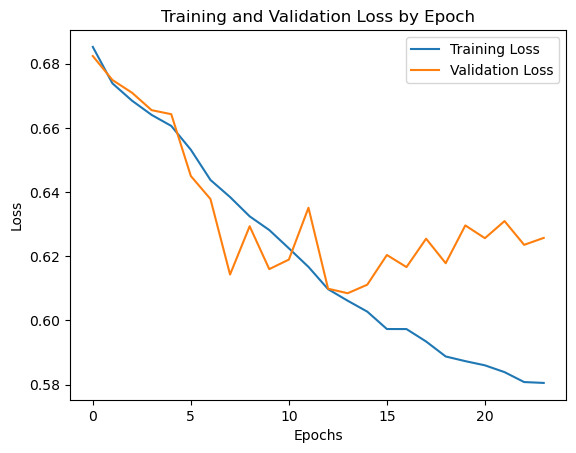

In [122]:
# Plot training and validation loss
plt.plot(train_losses, label = 'Training Loss')
plt.plot(val_losses, label = 'Validation Loss')
plt.title('Training and Validation Loss by Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

/var/folders/sm/dt8s0j7j0glg1jfrlpndm0lw0000gn/T/ipykernel_6960/3675692363.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gru_mod

Final Results:
Training Loss: 0.5805, Validation Loss: 0.6257, Test Loss: 0.6771, Test Accuracy: 0.6333
Precision: 0.6420, Recall: 0.6667, F1-score: 0.6541


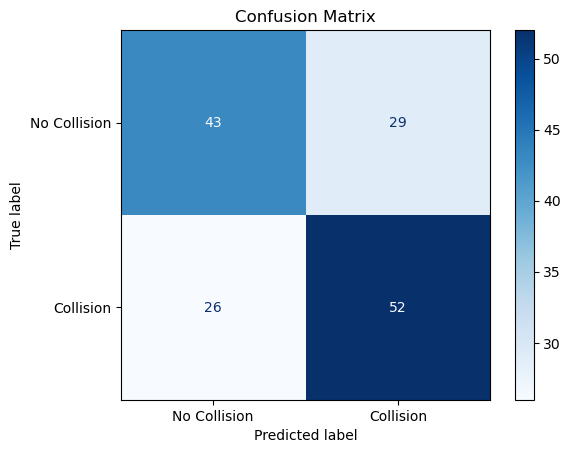

In [123]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()

test_loss = 0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue
        x_batch, lengths, y_batch = batch
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        outputs = model(x_batch, lengths)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Metrics
test_loss /= len(test_loader)
test_accuracy = correct / total
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print('Final Results:')
print(f'Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, '
      f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')
print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels = [0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Collision", "Collision"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
